# Hotel Reservations - предсказание отмены бронирования номеров в отелях

Отели теряют деньги, когда гости отменяют бронирование в последний момент. Заказчик хочет получить модель, которая будет предсказывать потенциальные отмены, чтобы лучше управлять доходами и заполняемостью номеров.


In [16]:
# Установка зависимостей
!pip install -r requirements.txt -q

In [17]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## 1 Обзор данных

In [18]:
# Загрузка датасета с кешированием на диске
try:
    df = pd.read_csv('./1. hotel.csv')
    print('Dataset found locally.')
except:
    print('Dataset not found locally.')
    df = pd.read_csv('https://code.s3.yandex.net/datasets/ds14_hotel.csv', index_col=0)
    df.to_csv('./1. hotel.csv')

Dataset found locally.


In [19]:
print("Описание числовых признаков:")
print(df.describe(include=[np.number]).T)
print()
print("Описание категориальных признаков:")
print(df.describe(include=["string"]).T)
print()

print(f"Размер выборки: {df.shape}\n")
print("Информация о признаках:")
print(df.info())

Описание числовых признаков:
                                        count         mean        std     min  \
no_of_adults                          24398.0     1.866464   0.550479     0.0   
no_of_children                        24398.0     0.119477   0.449286     0.0   
no_of_weekend_nights                  23169.0     0.918253   1.712215     0.0   
no_of_week_nights                     23175.0     2.394088   2.765744     0.0   
required_car_parking_space            23182.0     0.026184   0.159686     0.0   
lead_time                             24398.0    98.493565  92.427826     0.0   
arrival_year                          24398.0  2017.844291   0.362587  2017.0   
arrival_month                         24398.0     7.425568   2.971758     1.0   
arrival_date                          24398.0    15.661571   8.762291     1.0   
repeated_guest                        24398.0     0.019346   0.137740     0.0   
no_of_previous_cancellations          24398.0     0.018198   0.336463     0.0   

Распределение классов:
booking_status
False    12437
True     11961
Name: count, dtype: int64

Доля отменённых бронирований: 51.0%


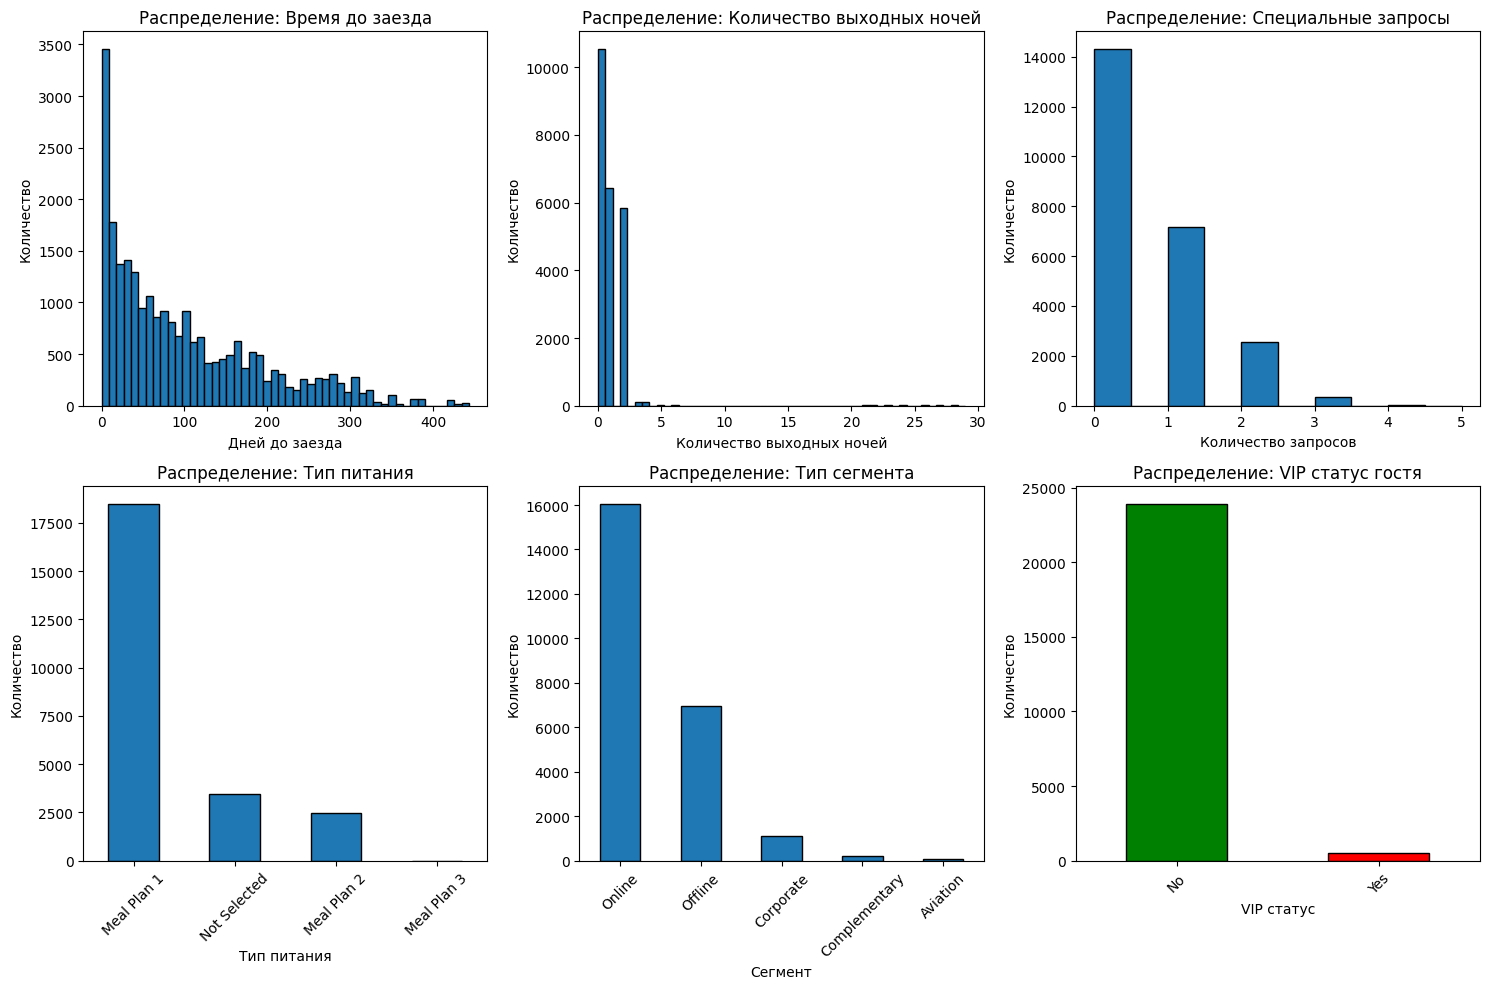

In [20]:
# Распределение целевой переменной
print("Распределение классов:")
print(df['booking_status'].value_counts())
print(f"\nДоля отменённых бронирований: {1-df.booking_status.mean():.1%}")

# Визуализация распределений ключевых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Время до заезда
axes[0, 0].hist(df['lead_time'], bins=50, edgecolor='black')
axes[0, 0].set_title('Распределение: Время до заезда')
axes[0, 0].set_xlabel('Дней до заезда')
axes[0, 0].set_ylabel('Количество')

# 2. Количество выходных ночей
axes[0, 1].hist(df['no_of_weekend_nights'], bins=50, edgecolor='black')
axes[0, 1].set_title('Распределение: Количество выходных ночей')
axes[0, 1].set_xlabel('Количество выходных ночей')
axes[0, 1].set_ylabel('Количество')

# 3. Количество специальных запросов
axes[0, 2].hist(df['no_of_special_requests'], bins=10, edgecolor='black')
axes[0, 2].set_title('Распределение: Специальные запросы')
axes[0, 2].set_xlabel('Количество запросов')
axes[0, 2].set_ylabel('Количество')

# 4. Тип питания
df['type_of_meal_plan'].value_counts().plot(kind='bar', ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title('Распределение: Тип питания')
axes[1, 0].set_xlabel('Тип питания')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Тип рыночного сегмента
df['market_segment_type'].value_counts().plot(kind='bar', ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title('Распределение: Тип сегмента')
axes[1, 1].set_xlabel('Сегмент')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Статус бронирования
df['is_vip_guest'].value_counts().plot(kind='bar', ax=axes[1, 2], edgecolor='black', color=['green', 'red'])
axes[1, 2].set_title('Распределение: VIP статус гостя')
axes[1, 2].set_xlabel('VIP статус')
axes[1, 2].set_ylabel('Количество')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

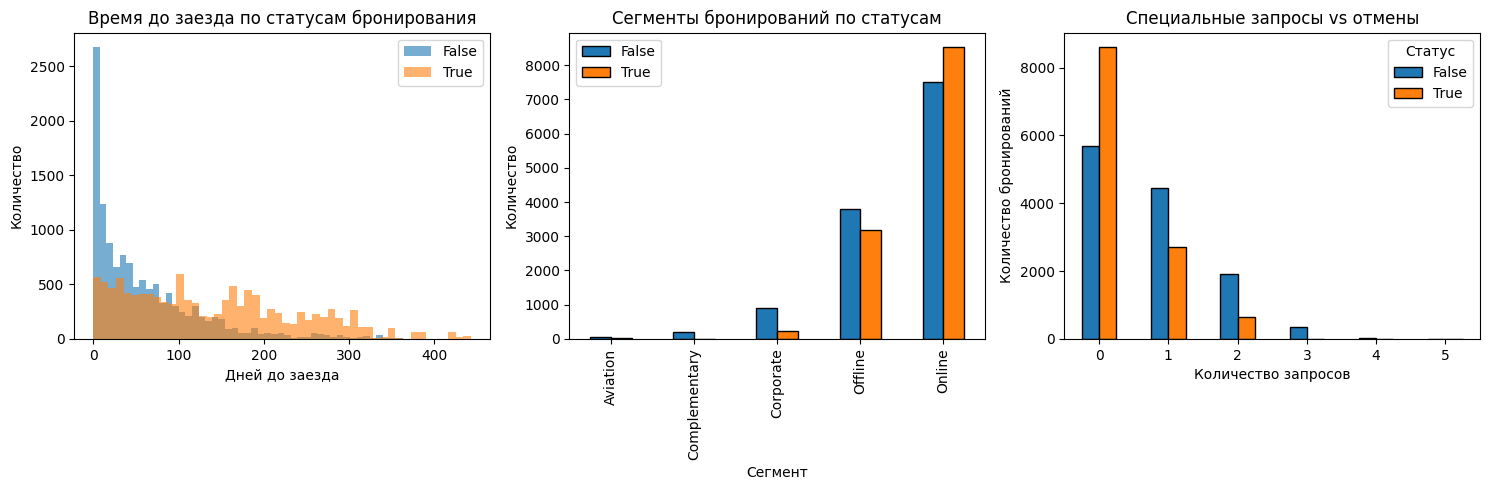

In [26]:
# Анализ связи признаков с целевой переменной
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Время до заезда vs отмены
for status in df['booking_status'].unique():
    subset = df[df['booking_status'] == status]
    axes[0].hist(subset['lead_time'], bins=50, alpha=0.6, label=status)
axes[0].set_title('Время до заезда по статусам бронирования')
axes[0].set_xlabel('Дней до заезда')
axes[0].set_ylabel('Количество')
axes[0].legend()

# Сегменты бронирований vs отмены
grouped = df.groupby(['market_segment_type', 'booking_status']).size().unstack()
grouped.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Сегменты бронирований по статусам')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('Количество')
axes[1].legend()

# Специальные запросы vs отмены
grouped = df.groupby(['no_of_special_requests', 'booking_status']).size().unstack()
grouped.plot(kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_title('Специальные запросы vs отмены')
axes[2].set_xlabel('Количество запросов')
axes[2].set_ylabel('Количество бронирований')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Статус')

plt.tight_layout()
plt.show()

## 2 Обучение модели

In [21]:
from sklearn.model_selection import train_test_split

# Разделяем на признаки и целевую переменную
X = df.drop(["Booking_ID", "booking_status"], axis=1)
y = df["booking_status"]

# Разделяем на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.impute import SimpleImputer

# Признаки с пропусками
numerical_with_nan = ['no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space']
X_with_nan = df[numerical_with_nan]

EMPTY_FEATURE_VALUE = -999999

# SimpleImputer с fill_value=-999999
imputer = SimpleImputer(fill_value=EMPTY_FEATURE_VALUE)

In [23]:
from sklearn.preprocessing import OneHotEncoder

# Обычные категориальные признаки
categorical_features = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
binary_features = ['is_vip_guest']

# OneHotEncoder для обычных категориальных признаков
categorical_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# OneHotEncoder для бинарного признака с параметром drop='first'
binary_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

In [24]:
from sklearn.compose import ColumnTransformer

# ColumnTransformer с тремя трансформерами
preprocessor = ColumnTransformer([
    ('binary', binary_encoder, binary_features),
    ('categorical', categorical_encoder, categorical_features),
    ('imputer', imputer, numerical_with_nan)
], remainder='passthrough')

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Инициализируем модель
model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Создадим Pipeline с preprocessor и DecisionTreeClassifier
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Обучим pipeline
pipeline.fit(X_train, y_train)

Accuracy на тестовой выборке: 0.847
ROC-AUC на тестовой выборке: 0.919


## 3. Оценка базовой модели

In [30]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Оценим модель по Accuracy и ROC-AUC одновременно с помощью кросс-валидации
cv_results = cross_validate(
    pipeline, X_train, y_train, cv=cv,
    scoring=['accuracy', 'roc_auc'],
    return_train_score=True
)

print("Базовая модель (без ограничений) - кросс-валидация на train:")
print(f"Accuracy: {cv_results['test_accuracy'].mean():.3f} (+/- {cv_results['test_accuracy'].std():.3f})")
print(f"ROC-AUC:  {cv_results['test_roc_auc'].mean():.3f} (+/- {cv_results['test_roc_auc'].std():.3f})")
print()
print(f"Accuracy на train: {cv_results['train_accuracy'].mean():.3f} (+/- {cv_results['train_accuracy'].std():.3f})")
print(f"ROC-AUC на train: {cv_results['train_roc_auc'].mean():.3f} (+/- {cv_results['train_roc_auc'].std():.3f})")

Базовая модель (без ограничений) - кросс-валидация на train:
Accuracy: 0.839 (+/- 0.008)
ROC-AUC:  0.913 (+/- 0.005)

Accuracy на train: 0.861 (+/- 0.003)
ROC-AUC на train: 0.942 (+/- 0.001)


In [31]:
overfit_pipeline = pipeline.fit(X_train, y_train)

tree = overfit_pipeline.steps[-1][-1]

print(f"Глубина переобученного дерева: {tree.get_depth()}")
print(f"Количество листьев переобученного дерева: {tree.get_n_leaves()}")

Глубина переобученного дерева: 10
Количество листьев переобученного дерева: 324


## 4. Подбор гиперпараметров

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth': [7, 10],
    'model__min_samples_split': [20, 50, 100],
    'model__min_samples_leaf': [10, 50],
    'model__max_leaf_nodes': [50, 100, 500, None]
}

# Инициализируйте GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='roc_auc',
    cv=cv
)

grid_search.fit(X_train, y_train)

print("\nЛучшая комбинация параметров:")
print(grid_search.best_params_) # Выведите лучшую комбинацию
print(f"Лучшее значение ROC-AUC: {grid_search.best_score_:.3f}")


Лучшая комбинация параметров:
{'model__max_depth': 10, 'model__max_leaf_nodes': 500, 'model__min_samples_leaf': 10, 'model__min_samples_split': 20}
Лучшее значение ROC-AUC: 0.915


In [34]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Создайте финальный пайплайн с лучшими параметрами
final_pipeline = grid_search.best_estimator_

# Обучите финальный пайплайн
final_pipeline.fit(X_train, y_train)

# Получите предсказания и вероятности
y_test_pred = final_pipeline.predict(X_test)
y_test_proba = final_pipeline.predict_proba(X_test)[:,1]

# Посчитайте метрики
accuracy_test = accuracy_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

# Выведите результаты
print("Модель с оптимальными параметрами:")
print(f"Accuracy test:  {accuracy_test:.3f}")
print(f"ROC-AUC test:   {roc_auc_test:.3f}")

Модель с оптимальными параметрами:
Accuracy test:  0.843
ROC-AUC test:   0.920


In [35]:
# Оцениваем модель по Accuracy и ROC-AUC одновременно
cv_results = cross_validate(final_pipeline, X_train, y_train, cv=cv,
                            scoring=['accuracy', 'roc_auc'], return_train_score=True)



# Выводим результаты
print("Улучшенная модель - кросс-валидация на test:")
print(f"Accuracy: {cv_results['test_accuracy'].mean():.3f} (+/- {cv_results['test_accuracy'].std():.3f})")
print(f"ROC-AUC:  {cv_results['test_roc_auc'].mean():.3f} (+/- {cv_results['test_roc_auc'].std():.3f})")
print()
print(f"Accuracy на train: {cv_results['train_accuracy'].mean():.3f} (+/- {cv_results['train_accuracy'].std():.3f})")
print(f"ROC-AUC на train: {cv_results['train_roc_auc'].mean():.3f} (+/- {cv_results['train_roc_auc'].std():.3f})")

Улучшенная модель - кросс-валидация на test:
Accuracy: 0.835 (+/- 0.009)
ROC-AUC:  0.915 (+/- 0.005)

Accuracy на train: 0.849 (+/- 0.003)
ROC-AUC на train: 0.933 (+/- 0.001)
